<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/Homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml, load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris()
X_iris = iris.data

print("Iris data shape:", X_iris.shape)
print("Features:", list(iris.feature_names))

Iris data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=11, n_init=10)
    kmeans.fit(X_iris)
    wcss.append(kmeans.inertia_)

for k, inertia in zip(k_values, wcss):
    print(f"k={k:2d}  WCSS={inertia:8.3f}")

k= 1  WCSS= 681.371
k= 2  WCSS= 152.348
k= 3  WCSS=  78.851
k= 4  WCSS=  57.228
k= 5  WCSS=  46.446
k= 6  WCSS=  39.066
k= 7  WCSS=  34.298
k= 8  WCSS=  30.063
k= 9  WCSS=  28.025
k=10  WCSS=  26.393


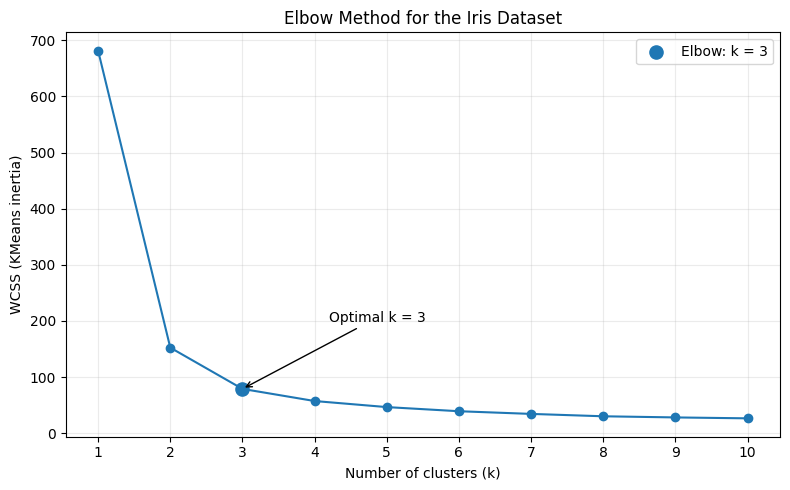

The elbow occurs at k = 3, so the optimal number of clusters is 3.


In [4]:
optimal_k = 3

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wcss, marker="o")
plt.scatter(optimal_k, wcss[optimal_k - 1], s=90, zorder=3, label="Elbow: k = 3")
plt.annotate(
    "Optimal k = 3",
    xy=(optimal_k, wcss[optimal_k - 1]),
    xytext=(4.2, wcss[optimal_k - 1] + 120),
    arrowprops={"arrowstyle": "->"},
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (KMeans inertia)")
plt.title("Elbow Method for the Iris Dataset")
plt.xticks(list(k_values))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("elbow-1.jpg", dpi=200, bbox_inches="tight")
plt.show()

print("The elbow occurs at k = 3, so the optimal number of clusters is 3.")

In [5]:
# version=1 pins the dataset version for reproducibility.
# as_frame=False returns NumPy arrays and avoids pandas overhead.
try:
    mnist = fetch_openml(
        'mnist_784', version=1, as_frame=False, parser='auto'
    )
    X_mnist = mnist.data.astype(np.float32)
    y_mnist = mnist.target.astype(np.uint8)
    print("MNIST data shape:", X_mnist.shape)
    print("MNIST target shape:", y_mnist.shape)
except Exception as error:
    X_mnist = y_mnist = None
    print("MNIST could not be downloaded in this restricted environment.")
    print("Run all cells in Google Colab or another internet-connected Jupyter environment.")
    print("Error type:", type(error).__name__)

MNIST data shape: (70000, 784)
MNIST target shape: (70000,)


In [6]:
if X_mnist is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_mnist,
        y_mnist,
        test_size=0.20,
        random_state=11,
        stratify=y_mnist,
    )
    print("Training set:", X_train.shape, y_train.shape)
    print("Testing set: ", X_test.shape, y_test.shape)

Training set: (56000, 784) (56000,)
Testing set:  (14000, 784) (14000,)


In [7]:
if X_mnist is not None:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("Standardized training shape:", X_train_scaled.shape)

Standardized training shape: (56000, 784)


In [8]:
if X_mnist is not None:
    logistic_without_pca = LogisticRegression(
        solver='lbfgs', max_iter=1000
    )

    start = perf_counter()
    logistic_without_pca.fit(X_train_scaled, y_train)
    time_without_pca = perf_counter() - start

    predictions_without_pca = logistic_without_pca.predict(X_test_scaled)
    accuracy_without_pca = accuracy_score(y_test, predictions_without_pca)

    print(f"Logistic-regression fit time without PCA: {time_without_pca:.3f} seconds")
    print(f"Accuracy without PCA: {accuracy_without_pca:.4f} ({accuracy_without_pca:.2%})")

Logistic-regression fit time without PCA: 94.578 seconds
Accuracy without PCA: 0.9138 (91.38%)


In [9]:
if X_mnist is not None:
    pca = PCA(n_components=0.95, random_state=11)

    start = perf_counter()
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    pca_time = perf_counter() - start

    print(f"PCA dimensions: {X_train_scaled.shape[1]} -> {pca.n_components_}")
    print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.4f}")
    print(f"One-time PCA fit/transform time: {pca_time:.3f} seconds")

PCA dimensions: 784 -> 331
Explained variance retained: 0.9503
One-time PCA fit/transform time: 1.459 seconds


In [10]:
if X_mnist is not None:
    logistic_with_pca = LogisticRegression(
        solver='lbfgs', max_iter=1000
    )

    start = perf_counter()
    logistic_with_pca.fit(X_train_pca, y_train)
    time_with_pca = perf_counter() - start

    predictions_with_pca = logistic_with_pca.predict(X_test_pca)
    accuracy_with_pca = accuracy_score(y_test, predictions_with_pca)

    print(f"Logistic-regression fit time with PCA: {time_with_pca:.3f} seconds")
    print(f"Accuracy with PCA: {accuracy_with_pca:.4f} ({accuracy_with_pca:.2%})")

Logistic-regression fit time with PCA: 51.840 seconds
Accuracy with PCA: 0.9219 (92.19%)


In [11]:
if X_mnist is not None:
    speedup = time_without_pca / time_with_pca
    time_saved = time_without_pca - time_with_pca
    accuracy_change = accuracy_with_pca - accuracy_without_pca
    total_first_run_with_pca = pca_time + time_with_pca

    print(f"{'Method':<22}{'LR fit time (s)':>18}{'Accuracy':>14}")
    print("-" * 54)
    print(f"{'Without PCA':<22}{time_without_pca:>18.3f}{accuracy_without_pca:>14.4f}")
    print(f"{'With PCA':<22}{time_with_pca:>18.3f}{accuracy_with_pca:>14.4f}")
    print(f"\nPCA reduced logistic-regression fit time by {time_saved:.3f} seconds.")
    print(f"Logistic regression trained {speedup:.2f}x faster after PCA.")
    print(f"Accuracy change after PCA: {accuracy_change:+.4f}.")
    print(f"PCA preprocessing + first reduced-model fit: {total_first_run_with_pca:.3f} seconds.")

Method                   LR fit time (s)      Accuracy
------------------------------------------------------
Without PCA                       94.578        0.9138
With PCA                          51.840        0.9219

PCA reduced logistic-regression fit time by 42.738 seconds.
Logistic regression trained 1.82x faster after PCA.
Accuracy change after PCA: +0.0081.
PCA preprocessing + first reduced-model fit: 53.299 seconds.
